<a href="https://colab.research.google.com/github/Anushka-2906/BEE/blob/main/Q5_V_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q5. V-Plot

Mounted at /content/drive
Found dataset at: /content/drive/MyDrive/bee coding/mapped.bed


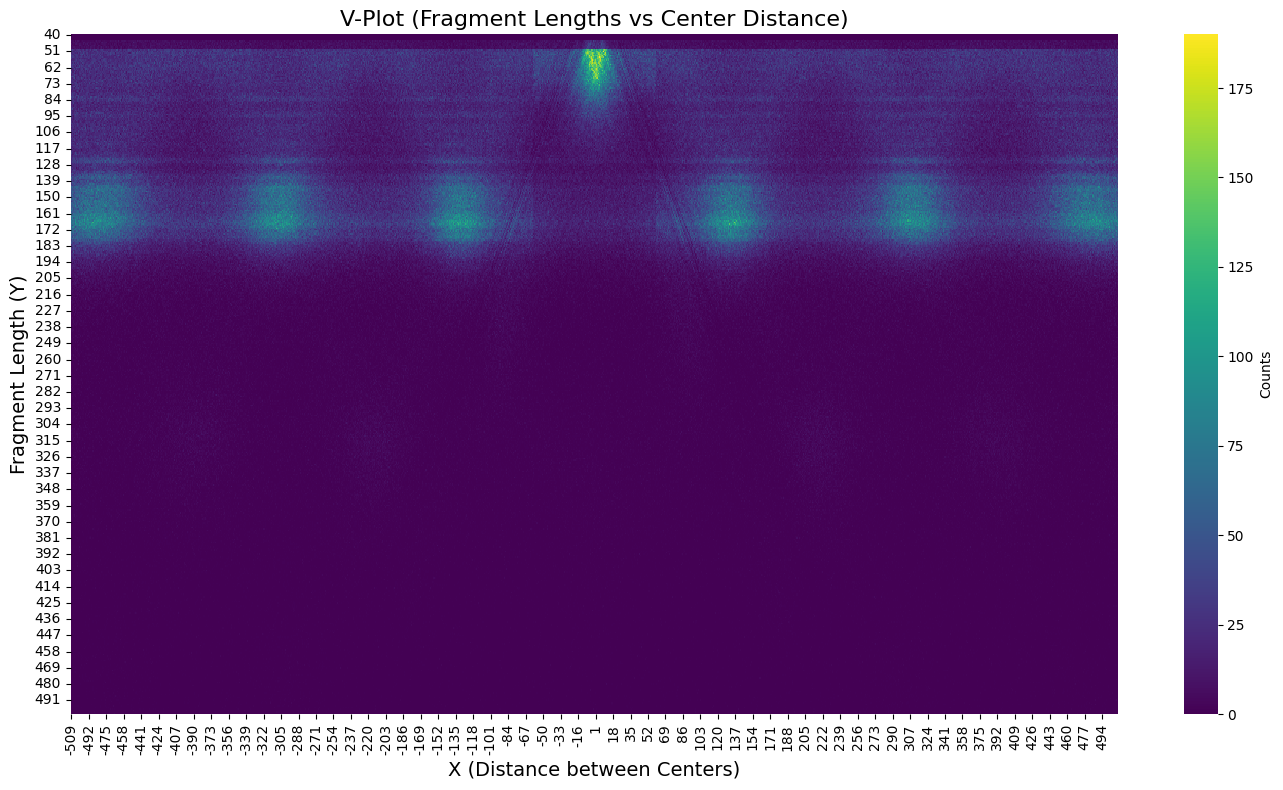

In [ ]:
#  Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#  Step 2: Search for the dataset
import os

search_root = '/content/drive/MyDrive/bee coding'
target_filename = 'mapped.bed'  # Correct filename

found_path = None
for root, dirs, files in os.walk(search_root):
    if target_filename in files:
        found_path = os.path.join(root, target_filename)
        break

if not found_path:
    raise FileNotFoundError(f"{target_filename} not found in {search_root}")

print(f"Found dataset at: {found_path}")

#  Step 3: Read the dataset and prepare X, Y
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Corrected function to load X (center difference) and Y (fragment length)
def load_vplot_data(filepath):
    data = []
    with open(filepath, 'r') as f:  # ❗ Fixed: use open() not gzip.open()
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            parts = line.strip().split()
            try:
                if len(parts) >= 13:
                    start1 = int(parts[2])  # Column 3 (0-based index 2)
                    end1 = int(parts[3])    # Column 4
                    start2 = int(parts[8])  # Column 9
                    end2 = int(parts[9])    # Column 10
                    fragment_length = int(parts[11])  # Column 12

                    c1 = (start1 + end1) // 2
                    c2 = (start2 + end2) // 2
                    x = c2 - c1
                    y = fragment_length

                    if y > 0:
                        data.append((x, y))
            except (IndexError, ValueError):
                continue  # skip bad lines
    return data

# Load the data
xy_data = load_vplot_data(found_path)

if not xy_data:
    raise ValueError("No valid (X, Y) data extracted. Please check input file!")

#  Step 4: Create 2D matrix
counter = defaultdict(int)
for x, y in xy_data:
    counter[(x, y)] += 1

x_vals = [x for x, y in counter.keys()]
y_vals = [y for x, y in counter.keys()]
z_vals = [counter[(x, y)] for x, y in counter.keys()]

df = pd.DataFrame({'X': x_vals, 'Y': y_vals, 'Z': z_vals})

# Create pivot table
pivot_table = df.pivot_table(index='Y', columns='X', values='Z', fill_value=0)

#  Step 5: Plot the V-Plot
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='viridis', cbar_kws={'label': 'Counts'})
plt.title('V-Plot (Fragment Lengths vs Center Distance)', fontsize=16)
plt.xlabel('X (Distance between Centers)', fontsize=14)
plt.ylabel('Fragment Length (Y)', fontsize=14)
plt.tight_layout()
plt.show()
